## Downscaling and moving windows
- Downscaling DTM rasters to 30m to have same-level scale with LST images 
- computing moving windows and study the correlations with LST depending on the size of the window.

### Libraries and general paths

In [11]:
!pip install rasterio
!pip install tqdm


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.ndimage import uniform_filter
from rasterio import mask
import geopandas as gpd
from scipy.ndimage import convolve
from tqdm import tqdm  # Progress bar

In [13]:
lst_cropped_path = '../../datos-notebooks/0.LST/LST_cropped_celsius.tif' # values out of bound are 0
lst_clipped_path = '../../datos-notebooks/0.LST/LST_clipped_celsius.tif' #values out of bound are nan
dtm_path = '../../datos-notebooks/3.topography/dtm_mosaic.tif'

output_dir = '../../datos-notebooks/3.topography/dtm_30m/'
os.makedirs(output_dir, exist_ok=True)
dtm_resampled_path = os.path.join(output_dir, 'dtm_30m.tif')

bound = "../../datos-notebooks/bologne_boundary.geojson"
gdf = gpd.read_file(bound)


In [14]:
def save_raster(filename, array):
    profile = lst_profile.copy()
    profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    with rasterio.open(os.path.join(output_dir, filename), 'w', **profile) as dst:
        dst.write(array.astype(np.float32), 1)

### Downscaling to 30m aligned with LST raster

#### Downscale to 30m

In [15]:
# Read LST cropped to get reference profile
with rasterio.open(lst_cropped_path) as lst_ref:
    lst_profile = lst_ref.profile
    lst_transform = lst_ref.transform
    lst_crs = lst_ref.crs
    lst_shape = (lst_ref.height, lst_ref.width)

In [ ]:
with rasterio.open(dtm_path) as dtm_src:
    dtm_data = dtm_src.read(1)
    dtm_profile = dtm_src.profile
    nodata_val = dtm_src.nodata  

    # Force CRS if missing
    if dtm_src.crs is None:
        from rasterio.crs import CRS
        dtm_crs = CRS.from_epsg(7791)  
    else:
        dtm_crs = dtm_src.crs

    # Create output array
    dtm_resampled = np.empty(lst_shape, dtype=np.float32)
    
    # mask nodata values for rescaling
    if nodata_val is not None:
        dtm_masked = np.where(dtm_data == nodata_val, np.nan, dtm_data)
    else:
        dtm_masked = dtm_data.astype(np.float32)

    # Reproyectar / downscale usando promedio
    reproject(
        source=dtm_masked,
        destination=dtm_resampled,
        src_transform=dtm_src.transform,
        src_crs=dtm_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )

save_raster('dtm_30m.tif', dtm_resampled)


#### extract:
- mean elevation
- mean slope
- northness
- eastness
- aspect

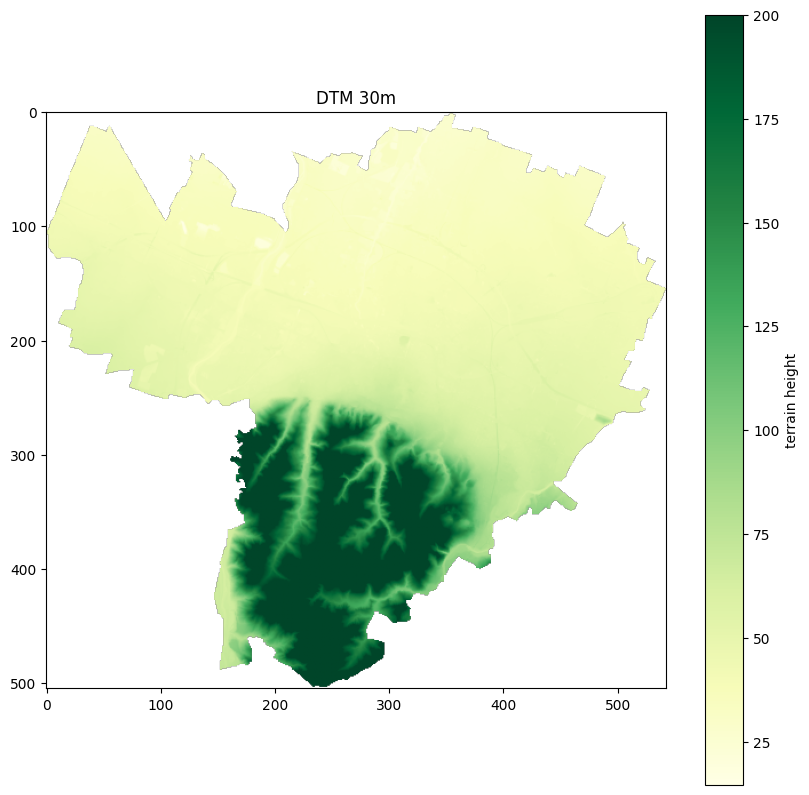

In [19]:
with rasterio.open(dtm_resampled_path) as src:
    dtm_resampled = src.read(1)
    
fig, ax = plt.subplots(figsize=(10,10))
img = ax.imshow(dtm_resampled, cmap='YlGn', vmax=200) 
ax.set_title("DTM 30m")
plt.colorbar(img, ax=ax, label="terrain height")
plt.show()


In [ ]:
# Compute slope and aspect

# Pixel size (xres, yres)
xres = lst_transform.a
yres = -lst_transform.e  

# Compute gradients
dz_dy, dz_dx = np.gradient(dtm_resampled, yres, xres)

# Remove padding
dz_dy = dz_dy[1:-1, 1:-1]
dz_dx = dz_dx[1:-1, 1:-1]

# Slope in radians
slope = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))

# Aspect (0 = North)
aspect = np.arctan2(dz_dx, -dz_dy)
aspect = np.where(aspect < 0, 2 * np.pi + aspect, aspect)

# Compute northness and eastness
northness = np.cos(aspect)
eastness = np.sin(aspect)

save_raster('elev_mean.tif', dtm_resampled)
save_raster('slope_mean.tif', np.degrees(slope))  # degrees
save_raster('northness.tif', northness)
save_raster('eastness.tif', eastness)

print("Finished. Files saved as elev_mean.tif, slope_mean.tif, northness.tif, eastness.tif")

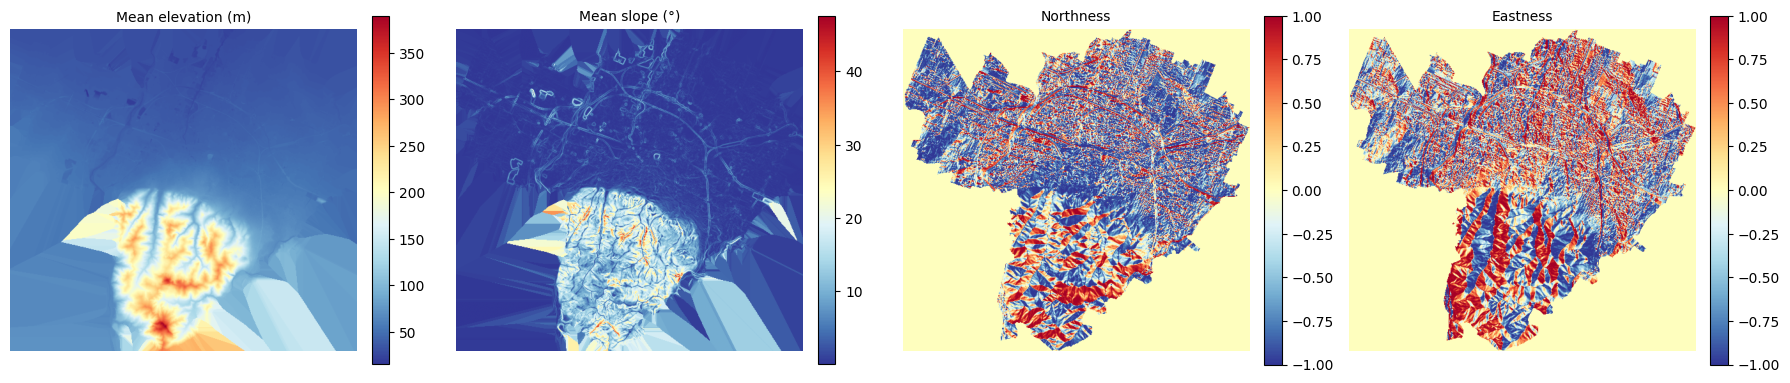

In [17]:
# plot
files = {
    "Mean elevation (m)": os.path.join(output_dir, "elev_mean.tif"),
    "Mean slope (°)": os.path.join(output_dir, "slope_mean.tif"),
    "Northness": os.path.join(output_dir, "northness.tif"),
    "Eastness": os.path.join(output_dir, "eastness.tif"), 
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (title, path) in zip(axes, files.items()):
    with rasterio.open(path) as src:
        data = src.read(1)
        data = np.where(np.isfinite(data), data, np.nan)  # mask invalid values

    cmap = 'terrain' if 'Elevación' in title else 'RdYlBu_r'

    if 'elevation' in title:
        im = ax.imshow(data, cmap=cmap)  
    else:
        im = ax.imshow(data, cmap=cmap)

    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
def fill_nan_nearest(array):
    """Fill NaN values with nearest valid neighbor."""
    mask = np.isnan(array)
    if np.any(mask):
        indices = ndimage.distance_transform_edt(
            mask,
            return_distances=False,
            return_indices=True
        )
        filled = array.copy()
        filled[mask] = array[tuple(indices[:, mask])]
        return filled
    else:
        return array

# List of rasters and names
rasters = [
    ("elev_mean.tif", dtm_resampled),
    ("slope_mean.tif", np.degrees(slope)),
    ("northness.tif", northness),
    ("eastness.tif", eastness),
]

for i, (name, array) in enumerate(rasters):
    if i < 2:
        # Fill with nearest neighbor only for elevation and slope
        array_filled = fill_nan_nearest(array)
    else:
        # Replace NaN with 0 for northness and eastness
        array_filled = np.where(np.isnan(array), 0, array)
    
    save_raster(name, array_filled)

print("Finished. Rasters filled.")



### Moving windows

In [ ]:
files = {
    "elev_mean": os.path.join(output_dir, "elev_mean.tif"),
    "slope_mean": os.path.join(output_dir, "slope_mean.tif"),
    "northness": os.path.join(output_dir, "northness.tif"),
    "eastness": os.path.join(output_dir, "eastness.tif"),
} 

def distance_weighted_kernel(size):
    """Create a distance-weighted Gaussian kernel."""
    assert size % 2 == 1, #Size must be odd
    center = size // 2
    y, x = np.ogrid[:size, :size]
    distance = np.sqrt((x - center)**2 + (y - center)**2)
    sigma = size / 4
    weights = np.exp(-(distance**2) / (2 * sigma**2))
    weights /= weights.sum()  # normalize
    return weights

def moving_window_weighted(array, kernel):
    """Apply convolution with given kernel."""
    return convolve(array, kernel, mode='nearest')


In [ ]:
# visualyze weighted kernel
k = distance_weighted_kernel(11)

plt.imshow(k, cmap='viridis')
plt.colorbar(label="Weight")
plt.title("Distance-weighted Gaussian kernel (11x11)")
plt.show()

In [ ]:
# visualyze weight profile
plt.plot(k[k.shape[0]//2], label="Center row")
plt.plot(k[:, k.shape[1]//2], label="Center column")
plt.legend()
plt.title("Weights decay from center")
plt.show()

In [ ]:
max_window = 201

for var_name, path in tqdm(files.items(), desc="Variables"):  # Outer progress
    var_dir = os.path.join(output_dir, var_name)
    os.makedirs(var_dir, exist_ok=True)

    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile

    for w in tqdm(range(1, max_window+1, 2), desc=f"Windows {var_name}", leave=False):  # Inner progress
        kernel = distance_weighted_kernel(w)
        avg_window = moving_window_weighted(data, kernel)

        out_name = f"{var_name}_win{w}.tif"
        out_path = os.path.join(var_dir, out_name)
        profile.update(dtype=rasterio.float32, compress='lzw')
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(avg_window.astype(np.float32), 1)

print("Finished. All variables saved with distance-weighted moving windows.")


In [ ]:
# Compute relative elevation (micro-relief)
rel_dir = os.path.join(output_dir, "rel_elev")
os.makedirs(rel_dir, exist_ok=True)

max_window = 201  

rel_dir = os.path.join(output_dir, "rel_elev")
os.makedirs(rel_dir, exist_ok=True)

with rasterio.open(files["elev_mean"]) as src:
    elev = src.read(1).astype(np.float32)
    profile = src.profile

for w in range(1, max_window+1, 2):  # only odd
    kernel = distance_weighted_kernel(w)
    elev_mean_window = moving_window_weighted(elev, kernel)
    rel_elev = elev - elev_mean_window

    out_name = f"rel_elev_win{w}.tif"
    out_path = os.path.join(rel_dir, out_name)
    profile.update(dtype=rasterio.float32, compress='lzw')
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(rel_elev.astype(np.float32), 1)

print("Finished. Relative elevation rasters saved with distance-weighted moving windows.")

In [ ]:
# Plots
window_sizes = range(1, 21,2)  
variables = ["elev_mean", "slope_mean", "northness", "eastness", "rel_elev"]

for var_name in variables:
    var_folder = os.path.join(output_dir, var_name)
 
    # Create subplot grid
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for idx, w in enumerate(window_sizes):
        raster_path = os.path.join(var_folder, f"{var_name}_win{w}.tif")
        with rasterio.open(raster_path) as src_var:
            var_data = src_var.read(1).astype(float)

        # Plot
        im = axes[idx].imshow(var_data, cmap='terrain' if 'elev' in var_name else 'RdYlBu_r')
        axes[idx].set_title(f"Win {w}")
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

    plt.suptitle(f"{var_name} - Windows 1 to 10", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


### correlations with LST

In [20]:
# Clip LST raster 

with rasterio.open(lst_cropped_path) as src:
    # Convert boundary to raster CRS
    boundary_crs = gdf.to_crs(src.crs)
    geoms = [boundary_crs.geometry.union_all().__geo_interface__]  # avoids deprecation warning

    # Clip raster to city boundary
    clipped_arr, clipped_transform = mask.mask(
        src,
        geoms,
        crop=True,
        nodata=np.nan
    )

    # Convert to float and handle original nodata
    clipped_arr = clipped_arr.astype("float32")
    if src.nodata is not None:
        clipped_arr[clipped_arr == src.nodata] = np.nan

    # Remove extra dimensions
    clipped_arr = clipped_arr.squeeze()

    # Update metadata
    meta = src.meta.copy()
    meta.update({
        "height": clipped_arr.shape[0],
        "width": clipped_arr.shape[1],
        "transform": clipped_transform,
        "dtype": "float32",
        "nodata": np.nan
    })

# Save
with rasterio.open(lst_clipped_path, "w", **meta) as dst:
    dst.write(clipped_arr, 1)



In [21]:
with rasterio.open(lst_clipped_path) as lst:
    lst_crs = lst.crs
    lst_clip = lst.read(1)          
    lst_transform = lst.transform 

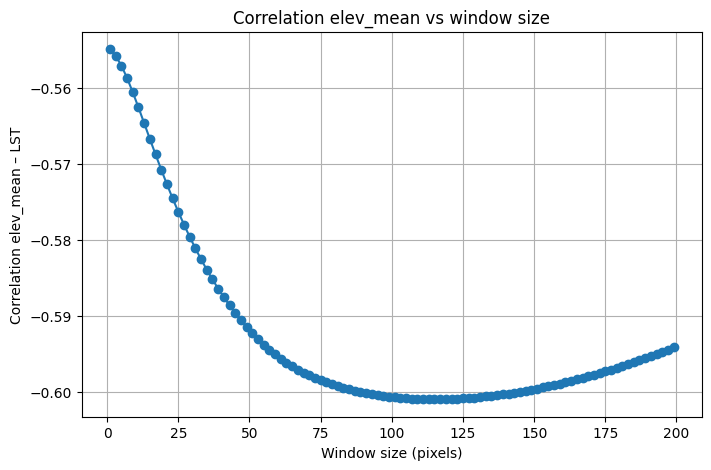

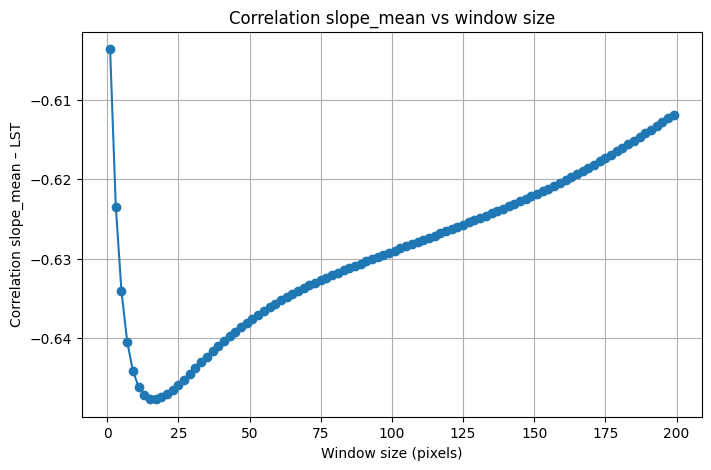

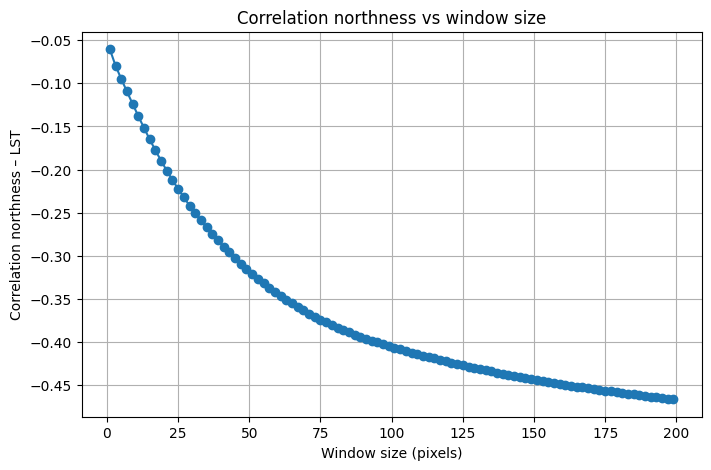

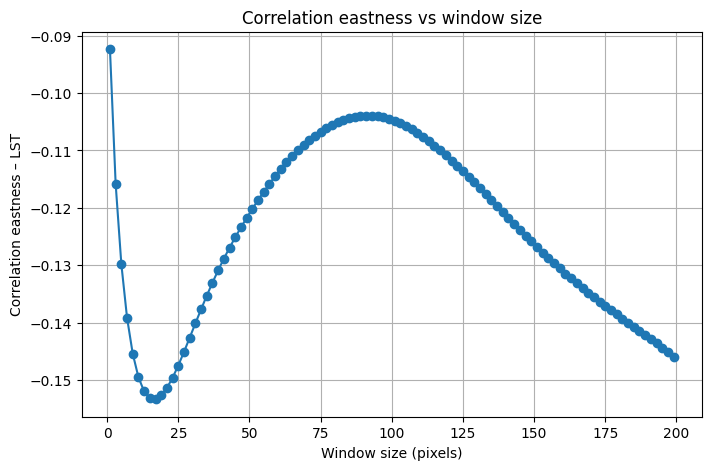

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


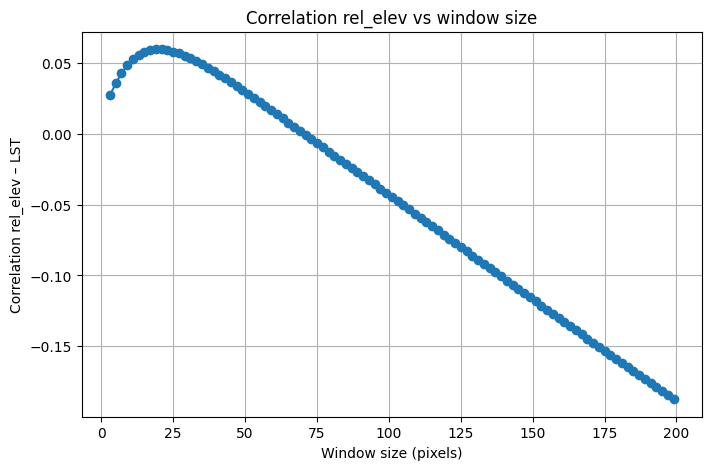

In [22]:
window_sizes = range(1, 201, 2) # only odd numbers

variables = ["elev_mean", "slope_mean", "northness", "eastness", "rel_elev"] #, "aspect"

for var_name in variables:
    var_folder = os.path.join(output_dir, var_name)
    correlations = []

    for w in window_sizes:
        raster_path = os.path.join(var_folder, f"{var_name}_win{w}.tif")
        with rasterio.open(raster_path) as src_var:
            var_data = src_var.read(1).astype(float)

        # Pixel-by-pixel correlation with LST
        valid_mask = ~np.isnan(lst_clip)  # only LST valid pixels
        lst_vals = lst_clip[valid_mask]
        var_vals = var_data[valid_mask]

        corr = np.corrcoef(var_vals, lst_vals)[0, 1]
        correlations.append(corr)

    # Plot correlation vs window size
    plt.figure(figsize=(8,5))
    plt.plot(window_sizes, correlations, marker='o')
    plt.xlabel("Window size (pixels)")
    plt.ylabel(f"Correlation {var_name} – LST")
    plt.title(f"Correlation {var_name} vs window size")
    plt.grid(True)
    plt.show()
